<a href="https://www.kaggle.com/code/omborse771924/tmdb-top-10-000-movies-updated-2026-eda?scriptVersionId=333411532" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/siddharthbhakta/tmdb-top-10000-movies-updated-2026/moviesTMBD.csv


In [2]:
df = pd.read_csv('/kaggle/input/datasets/siddharthbhakta/tmdb-top-10000-movies-updated-2026/moviesTMBD.csv')

In [3]:
df.head()

,Unnamed: 0,id,title,popularity,adult,original_language,overview,release_date,vote_average,vote_count
0,0,1007757,Swapped,327.5134,False,en,"A small woodland creature and a majestic bird,...",2026-05-01,8.987,1320
1,1,278,The Shawshank Redemption,65.3308,False,en,Imprisoned in the 1940s for the double murder ...,1994-09-23,8.721,30387
2,2,238,The Godfather,47.2346,False,en,"Spanning the years 1945 to 1955, a chronicle o...",1972-03-14,8.686,22929
3,3,687163,Project Hail Mary,422.0199,False,en,Science teacher Ryland Grace wakes up on a spa...,2026-03-15,8.621,3950
4,4,240,The Godfather Part II,27.6763,False,en,In the continuing saga of the Corleone crime f...,1974-12-20,8.571,13901


In [4]:
df.tail()

,Unnamed: 0,id,title,popularity,adult,original_language,overview,release_date,vote_average,vote_count
9975,9975,399173,The Assignment,2.1132,False,en,Ace assassin Frank Kitchen is double crossed b...,2016-06-08,5.538,560
9976,9976,613377,30 Days Max,1.2237,False,fr,Rayane is a scared and clumsy young cop who is...,2020-10-14,5.500,407
9977,9977,8859,"Dude, Where's My Car?",2.8157,False,en,Two stoners wake up after a night of partying ...,2000-12-15,5.538,2080
9978,9978,313943,Revolt,1.4022,False,en,The story of humankind's last stand against a ...,2017-07-01,5.537,393
9979,9979,277355,Everly,2.0746,False,en,"After she betrays a powerful mob boss, a woman...",2015-02-26,5.536,584


In [5]:
df.info

<bound method DataFrame.info of       Unnamed: 0       id                     title  popularity  adult  \
0              0  1007757                   Swapped    327.5134  False   
1              1      278  The Shawshank Redemption     65.3308  False   
2              2      238             The Godfather     47.2346  False   
3              3   687163         Project Hail Mary    422.0199  False   
4              4      240     The Godfather Part II     27.6763  False   
...          ...      ...                       ...         ...    ...   
9975        9975   399173            The Assignment      2.1132  False   
9976        9976   613377               30 Days Max      1.2237  False   
9977        9977     8859     Dude, Where's My Car?      2.8157  False   
9978        9978   313943                    Revolt      1.4022  False   
9979        9979   277355                    Everly      2.0746  False   

     original_language                                           overview  \
0 

In [6]:
df.isnull

<bound method DataFrame.isnull of       Unnamed: 0       id                     title  popularity  adult  \
0              0  1007757                   Swapped    327.5134  False   
1              1      278  The Shawshank Redemption     65.3308  False   
2              2      238             The Godfather     47.2346  False   
3              3   687163         Project Hail Mary    422.0199  False   
4              4      240     The Godfather Part II     27.6763  False   
...          ...      ...                       ...         ...    ...   
9975        9975   399173            The Assignment      2.1132  False   
9976        9976   613377               30 Days Max      1.2237  False   
9977        9977     8859     Dude, Where's My Car?      2.8157  False   
9978        9978   313943                    Revolt      1.4022  False   
9979        9979   277355                    Everly      2.0746  False   

     original_language                                           overview  \


In [7]:
df.isnull().sum()

Unnamed: 0           0
id                   0
title                0
popularity           0
adult                0
original_language    0
overview             2
release_date         2
vote_average         0
vote_count           0
dtype: int64

In [8]:
# Fill missing overview with a placeholder
df["overview"] = df["overview"].fillna("No Overview Available")

# Fill missing release_date with the most frequent date
df["release_date"] = df["release_date"].fillna(df["release_date"].mode()[0])

# Check again
print(df.isnull().sum())

Unnamed: 0           0
id                   0
title                0
popularity           0
adult                0
original_language    0
overview             0
release_date         0
vote_average         0
vote_count           0
dtype: int64


In [9]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
9975    False
9976    False
9977    False
9978    False
9979    False
Length: 9980, dtype: bool

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.columns

Index(['Unnamed: 0', 'id', 'title', 'popularity', 'adult', 'original_language',
       'overview', 'release_date', 'vote_average', 'vote_count'],
      dtype='object')

## EDA

Shape : (9980, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9980 entries, 0 to 9979
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         9980 non-null   int64  
 1   id                 9980 non-null   int64  
 2   title              9980 non-null   object 
 3   popularity         9980 non-null   float64
 4   adult              9980 non-null   bool   
 5   original_language  9980 non-null   object 
 6   overview           9980 non-null   object 
 7   release_date       9980 non-null   object 
 8   vote_average       9980 non-null   float64
 9   vote_count         9980 non-null   int64  
dtypes: bool(1), float64(2), int64(3), object(4)
memory usage: 711.6+ KB
None
         Unnamed: 0            id   title   popularity  adult  \
count   9980.000000  9.980000e+03    9980  9980.000000   9980   
unique          NaN           NaN    9105          NaN      1   
top             NaN      

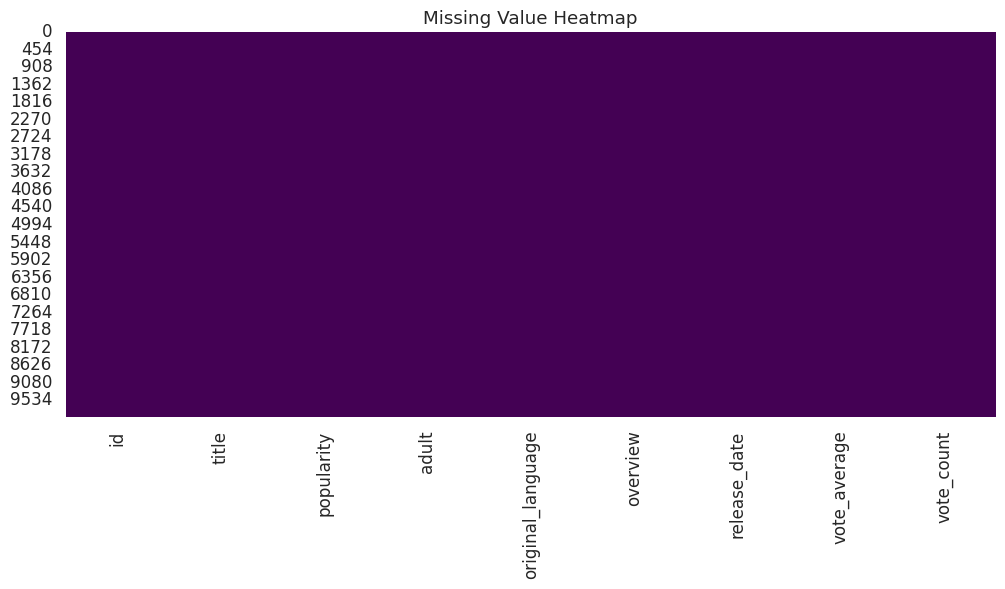

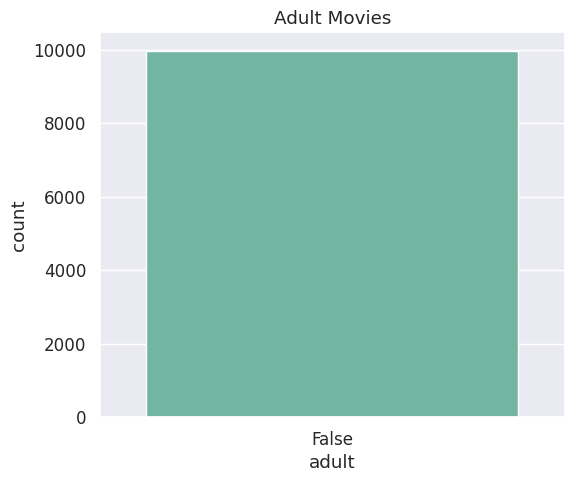

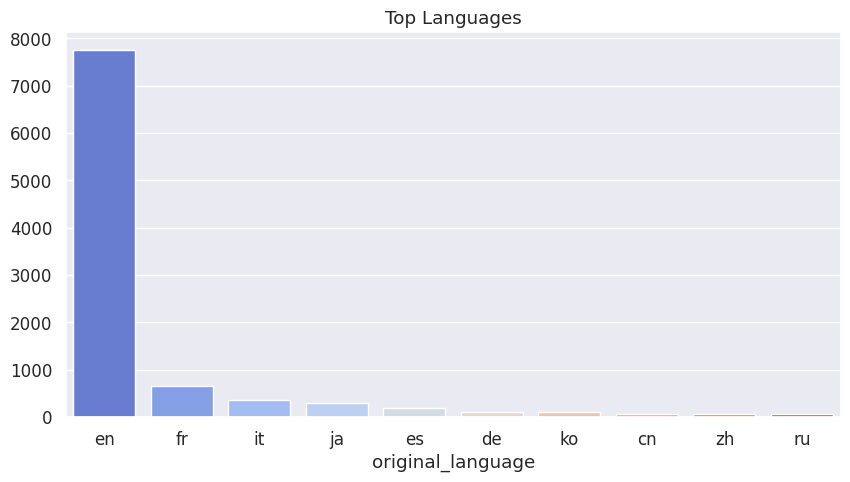

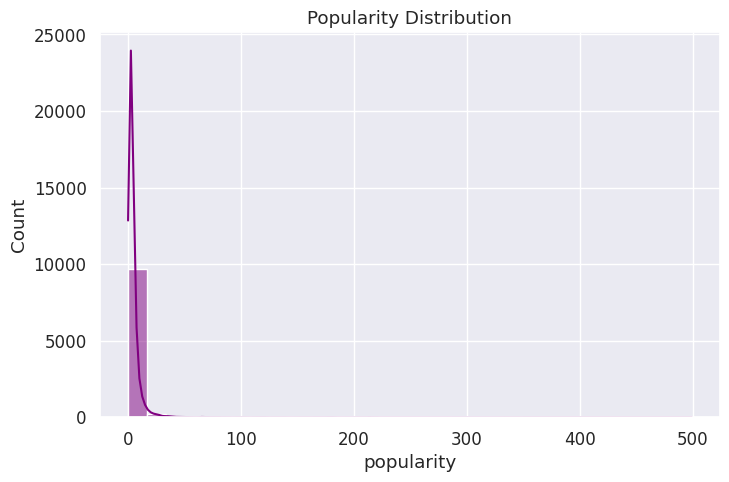

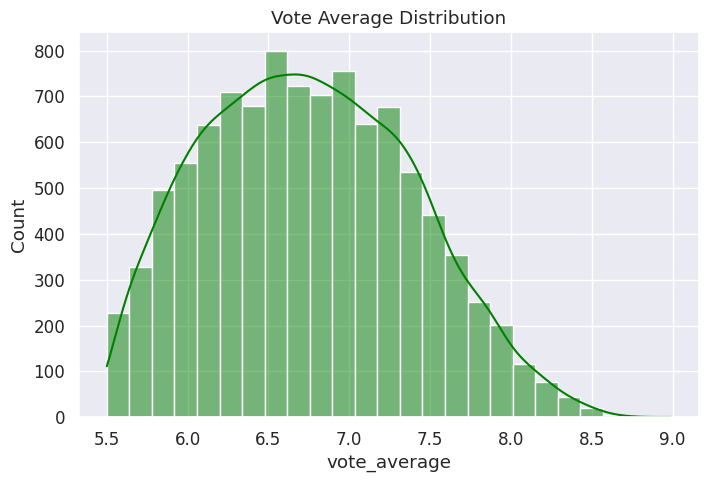

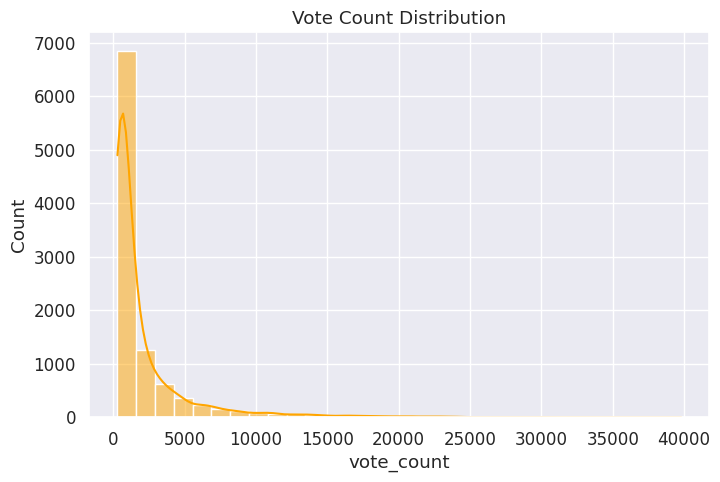

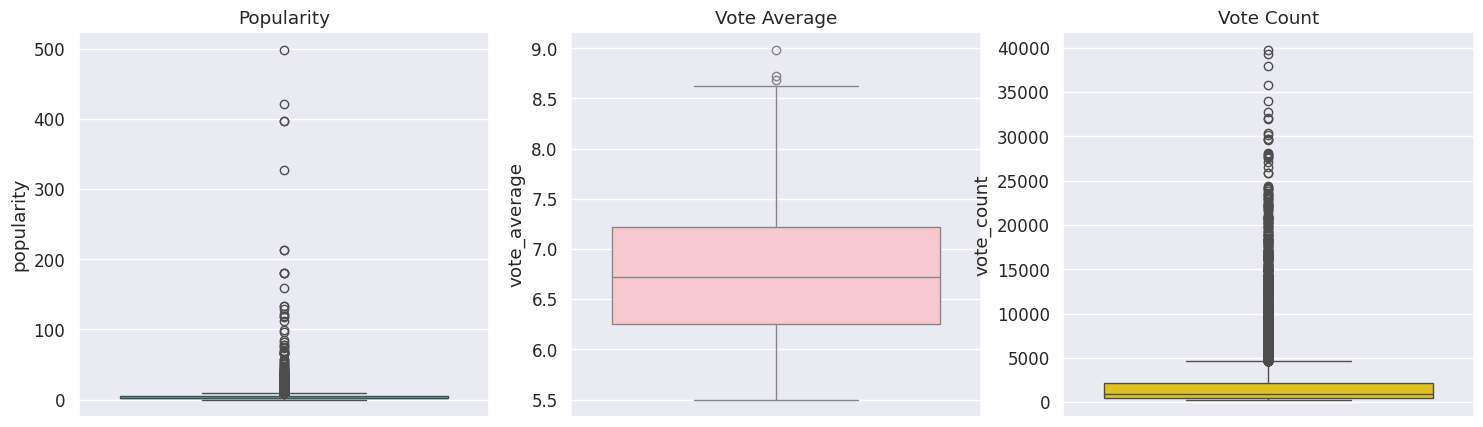

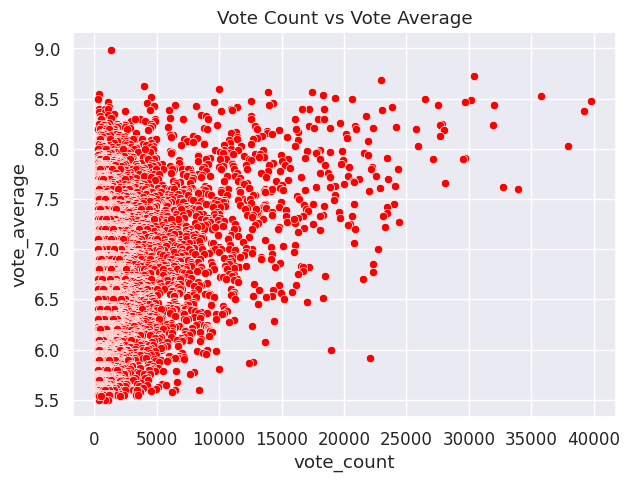

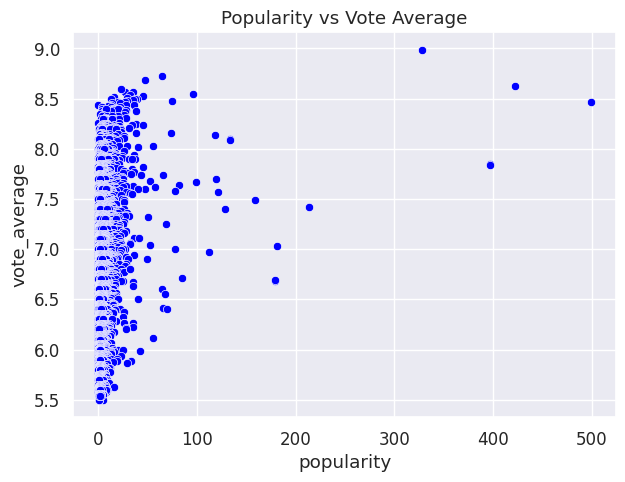

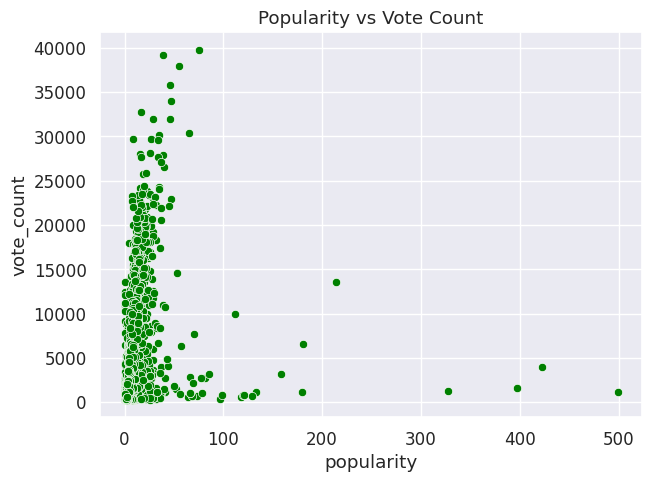

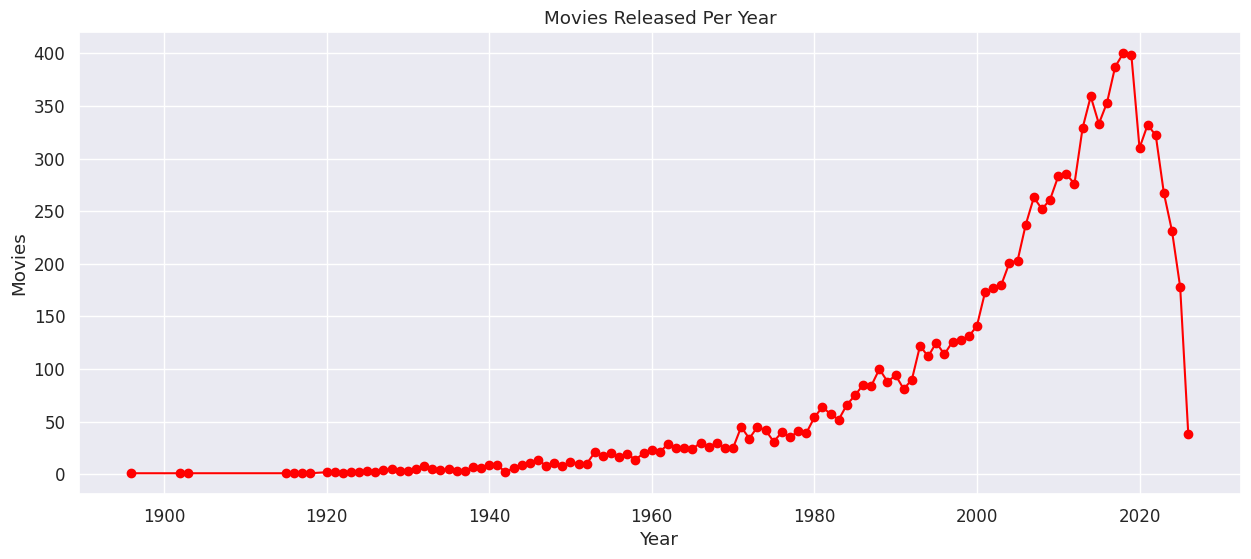

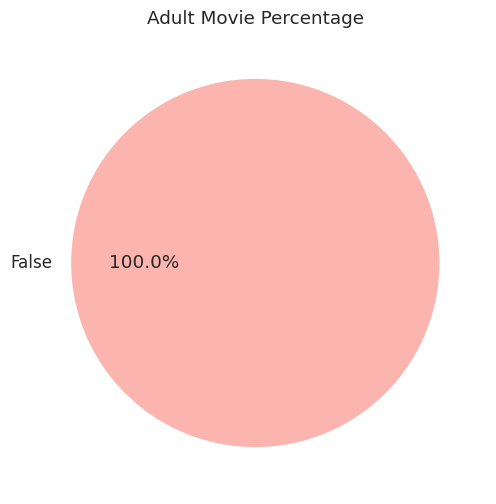

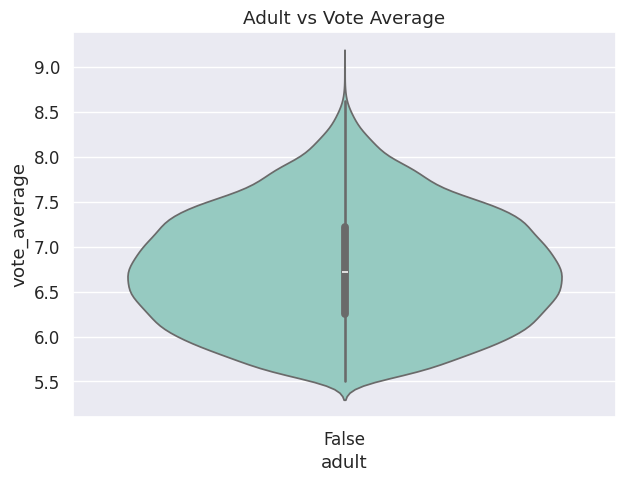

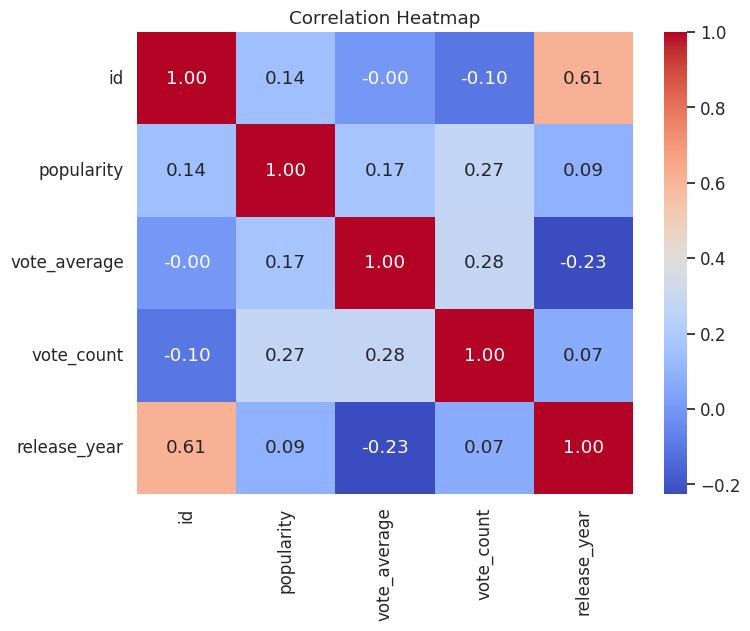

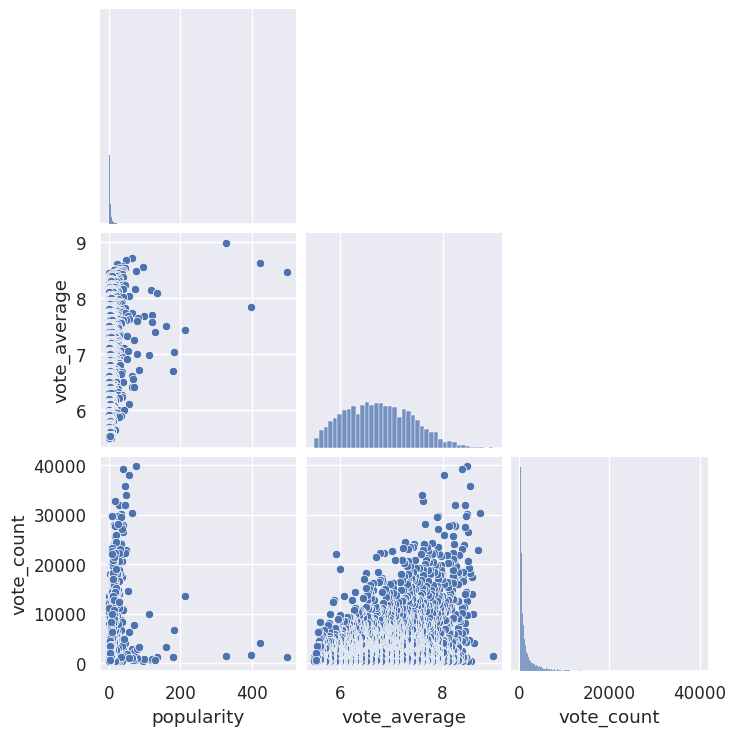

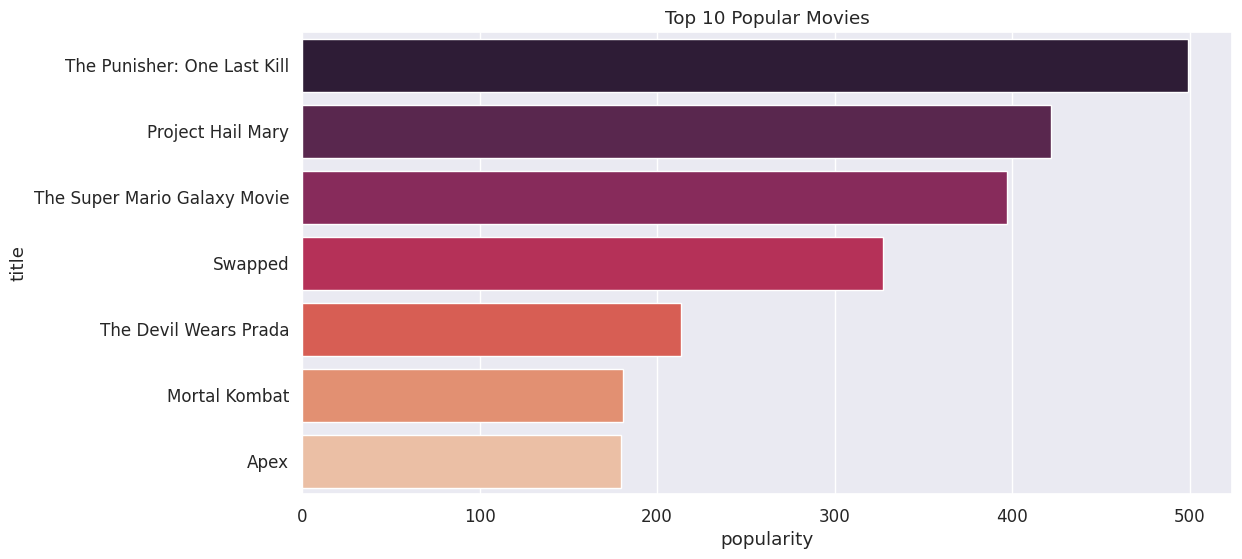

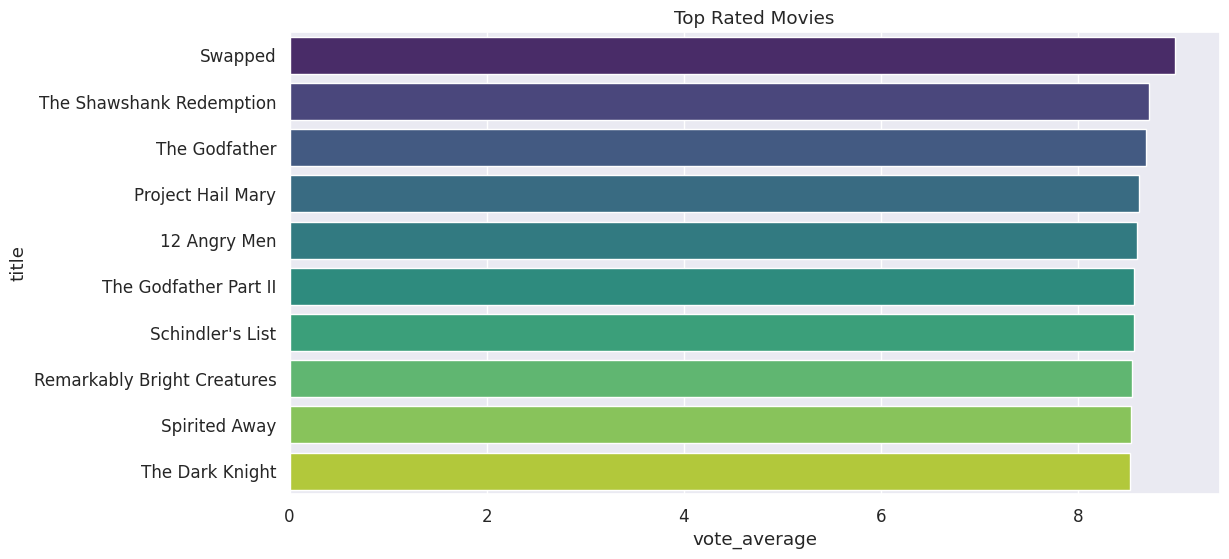

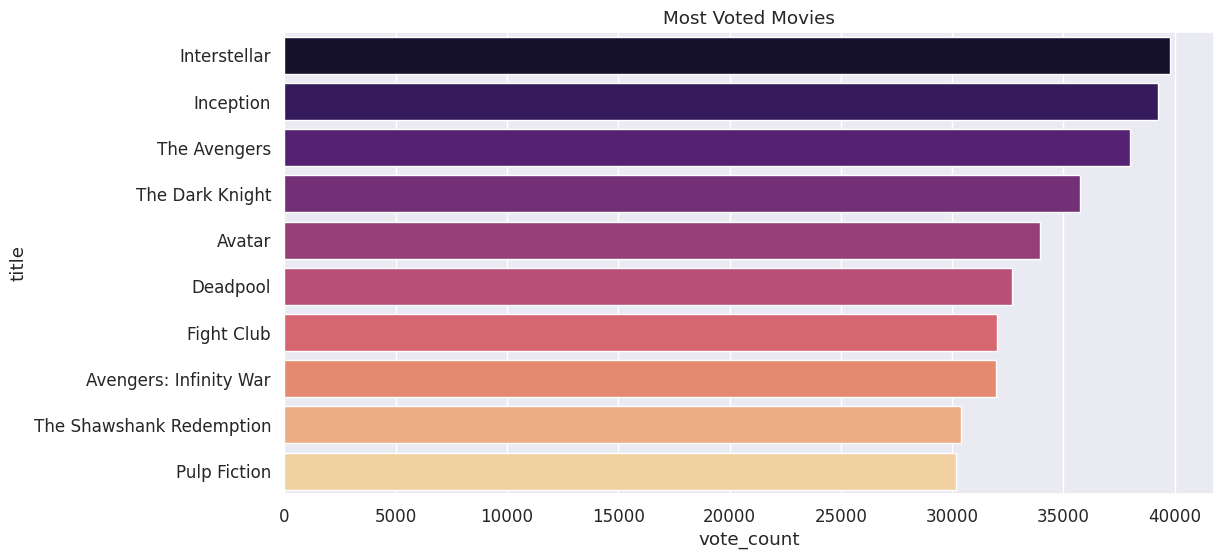

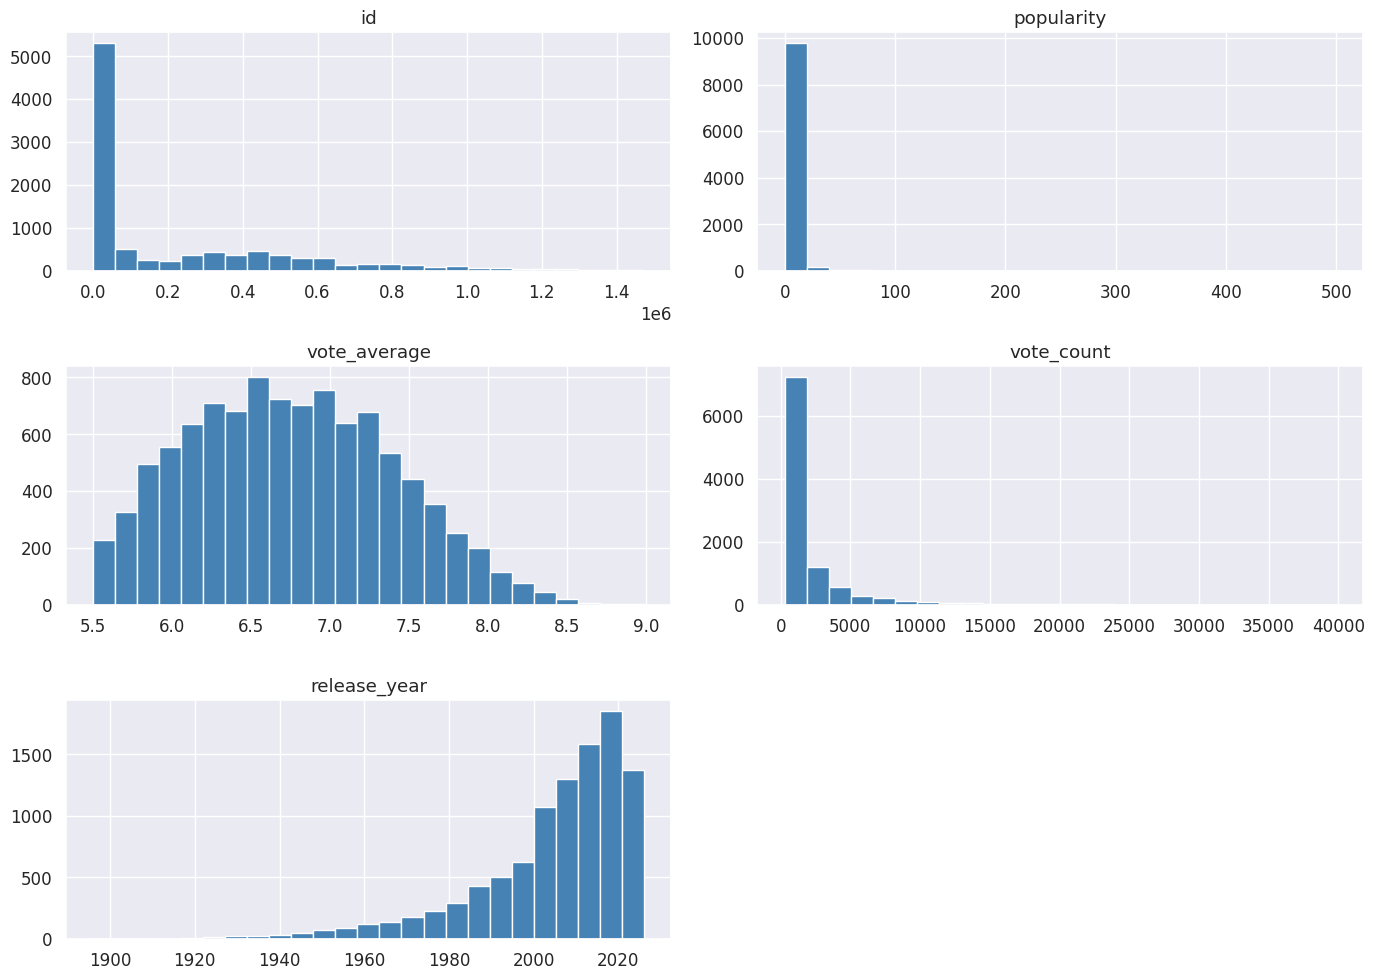

EDA COMPLETED SUCCESSFULLY


In [12]:
# ==========================================================
# IMPORT LIBRARIES
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
sns.set(font_scale=1.1)

data = df.copy()

# ==========================================================
# BASIC INFORMATION
# ==========================================================

print("="*60)
print("Shape :", data.shape)

print("="*60)
print(data.info())

print("="*60)
print(data.describe(include='all'))

print("="*60)
print(data.isnull().sum())

# ==========================================================
# DROP UNNECESSARY COLUMN
# ==========================================================

if "Unnamed: 0" in data.columns:
    data.drop(columns=["Unnamed: 0"], inplace=True)

# ==========================================================
# CONVERT RELEASE DATE
# ==========================================================

data["release_date"] = pd.to_datetime(
    data["release_date"],
    errors="coerce"
)

# ==========================================================
# MISSING VALUE HEATMAP
# ==========================================================

plt.figure(figsize=(12,5))

sns.heatmap(
    data.isnull(),
    cmap="viridis",
    cbar=False
)

plt.title("Missing Value Heatmap")

plt.show()

# ==========================================================
# ADULT MOVIES
# ==========================================================

plt.figure(figsize=(6,5))

sns.countplot(
    data=data,
    x="adult",
    palette="Set2"
)

plt.title("Adult Movies")

plt.show()

# ==========================================================
# ORIGINAL LANGUAGE
# ==========================================================

top_lang = data["original_language"].value_counts().head(10)

plt.figure(figsize=(10,5))

sns.barplot(
    x=top_lang.index,
    y=top_lang.values,
    palette="coolwarm"
)

plt.title("Top Languages")

plt.show()

# ==========================================================
# POPULARITY DISTRIBUTION
# ==========================================================

plt.figure(figsize=(8,5))

sns.histplot(
    data["popularity"],
    kde=True,
    bins=30,
    color="purple"
)

plt.title("Popularity Distribution")

plt.show()

# ==========================================================
# VOTE AVERAGE
# ==========================================================

plt.figure(figsize=(8,5))

sns.histplot(
    data["vote_average"],
    kde=True,
    bins=25,
    color="green"
)

plt.title("Vote Average Distribution")

plt.show()

# ==========================================================
# VOTE COUNT
# ==========================================================

plt.figure(figsize=(8,5))

sns.histplot(
    data["vote_count"],
    kde=True,
    bins=30,
    color="orange"
)

plt.title("Vote Count Distribution")

plt.show()

# ==========================================================
# BOXPLOTS
# ==========================================================

fig,axes=plt.subplots(1,3,figsize=(18,5))

sns.boxplot(y=data["popularity"],ax=axes[0],color="cyan")
axes[0].set_title("Popularity")

sns.boxplot(y=data["vote_average"],ax=axes[1],color="pink")
axes[1].set_title("Vote Average")

sns.boxplot(y=data["vote_count"],ax=axes[2],color="gold")
axes[2].set_title("Vote Count")

plt.show()

# ==========================================================
# SCATTER PLOTS
# ==========================================================

plt.figure(figsize=(7,5))

sns.scatterplot(
    data=data,
    x="vote_count",
    y="vote_average",
    color="red"
)

plt.title("Vote Count vs Vote Average")

plt.show()

plt.figure(figsize=(7,5))

sns.scatterplot(
    data=data,
    x="popularity",
    y="vote_average",
    color="blue"
)

plt.title("Popularity vs Vote Average")

plt.show()

plt.figure(figsize=(7,5))

sns.scatterplot(
    data=data,
    x="popularity",
    y="vote_count",
    color="green"
)

plt.title("Popularity vs Vote Count")

plt.show()

# ==========================================================
# RELEASE YEAR TREND
# ==========================================================

data["release_year"] = data["release_date"].dt.year

year_count = data["release_year"].value_counts().sort_index()

plt.figure(figsize=(15,6))

plt.plot(
    year_count.index,
    year_count.values,
    color="red",
    marker="o"
)

plt.title("Movies Released Per Year")

plt.xlabel("Year")

plt.ylabel("Movies")

plt.show()

# ==========================================================
# PIE CHART
# ==========================================================

plt.figure(figsize=(6,6))

data["adult"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    cmap="Pastel1"
)

plt.ylabel("")

plt.title("Adult Movie Percentage")

plt.show()

# ==========================================================
# VIOLIN PLOT
# ==========================================================

plt.figure(figsize=(7,5))

sns.violinplot(
    data=data,
    x="adult",
    y="vote_average",
    palette="Set3"
)

plt.title("Adult vs Vote Average")

plt.show()

# ==========================================================
# CORRELATION HEATMAP
# ==========================================================

plt.figure(figsize=(8,6))

corr = data.select_dtypes(include=np.number).corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

# ==========================================================
# PAIRPLOT
# ==========================================================

sns.pairplot(
    data[["popularity","vote_average","vote_count"]],
    corner=True
)

plt.show()

# ==========================================================
# TOP 10 POPULAR MOVIES
# ==========================================================

top = data.nlargest(10,"popularity")

plt.figure(figsize=(12,6))

sns.barplot(
    data=top,
    x="popularity",
    y="title",
    palette="rocket"
)

plt.title("Top 10 Popular Movies")

plt.show()

# ==========================================================
# TOP 10 HIGHEST RATED MOVIES
# ==========================================================

top_rating = data.nlargest(10,"vote_average")

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_rating,
    x="vote_average",
    y="title",
    palette="viridis"
)

plt.title("Top Rated Movies")

plt.show()

# ==========================================================
# TOP 10 MOST VOTED MOVIES
# ==========================================================

top_votes = data.nlargest(10,"vote_count")

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_votes,
    x="vote_count",
    y="title",
    palette="magma"
)

plt.title("Most Voted Movies")

plt.show()

# ==========================================================
# NUMERIC HISTOGRAM GRID
# ==========================================================

data.select_dtypes(include=np.number).hist(
    figsize=(14,10),
    bins=25,
    color="steelblue"
)

plt.tight_layout()

plt.show()

print("="*60)
print("EDA COMPLETED SUCCESSFULLY")
print("="*60)

## Features Engineering


Logistic Regression
Accuracy : 0.9949899799599199
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       278
           1       1.00      0.94      0.97        54
           2       1.00      1.00      1.00      1664

    accuracy                           0.99      1996
   macro avg       0.99      0.98      0.99      1996
weighted avg       0.99      0.99      0.99      1996



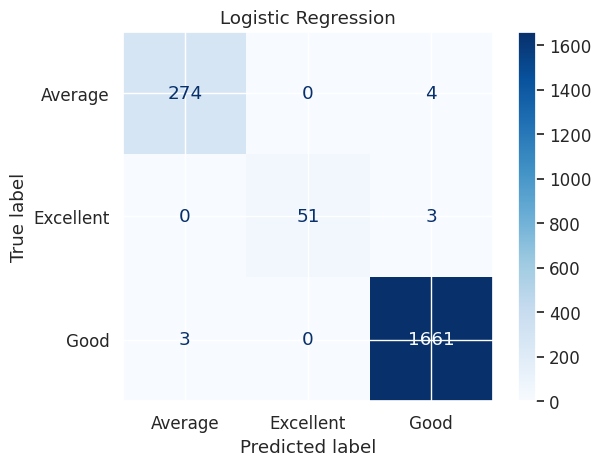

Decision Tree
Accuracy : 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       278
           1       1.00      1.00      1.00        54
           2       1.00      1.00      1.00      1664

    accuracy                           1.00      1996
   macro avg       1.00      1.00      1.00      1996
weighted avg       1.00      1.00      1.00      1996



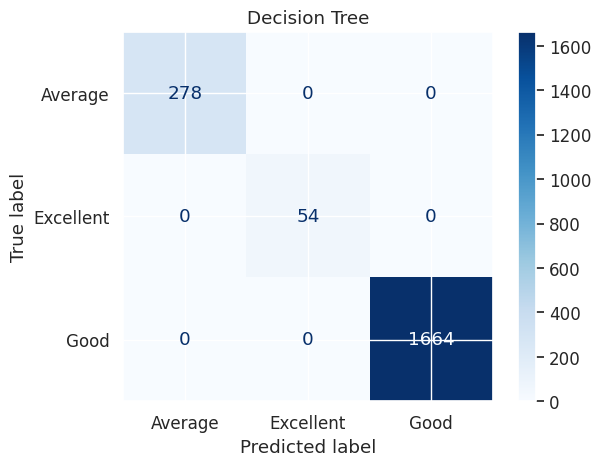

Random Forest
Accuracy : 0.998997995991984
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       278
           1       1.00      1.00      1.00        54
           2       1.00      1.00      1.00      1664

    accuracy                           1.00      1996
   macro avg       1.00      1.00      1.00      1996
weighted avg       1.00      1.00      1.00      1996



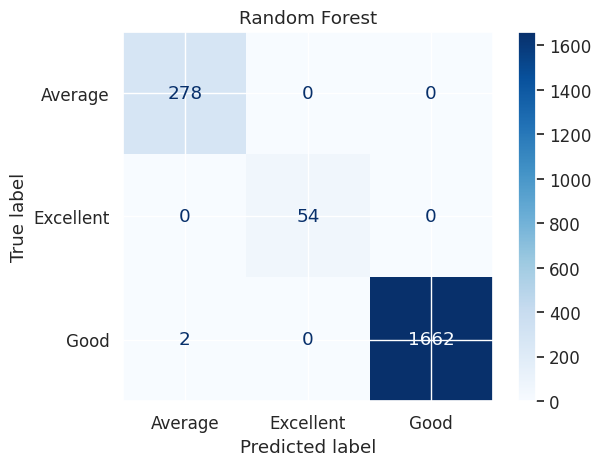

Gradient Boosting
Accuracy : 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       278
           1       1.00      1.00      1.00        54
           2       1.00      1.00      1.00      1664

    accuracy                           1.00      1996
   macro avg       1.00      1.00      1.00      1996
weighted avg       1.00      1.00      1.00      1996



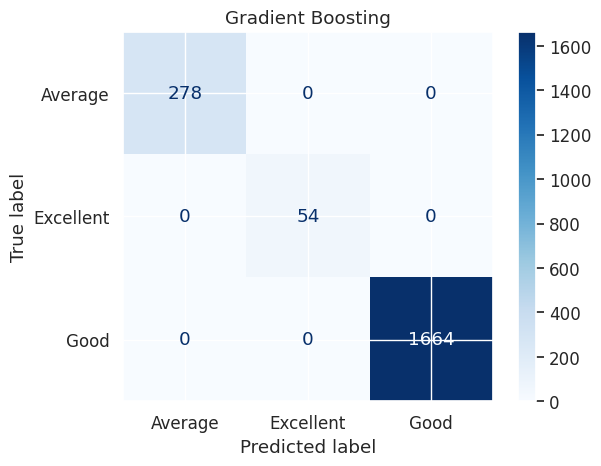

KNN
Accuracy : 0.9749498997995992
              precision    recall  f1-score   support

           0       0.96      0.96      0.96       278
           1       0.83      0.63      0.72        54
           2       0.98      0.99      0.99      1664

    accuracy                           0.97      1996
   macro avg       0.92      0.86      0.89      1996
weighted avg       0.97      0.97      0.97      1996



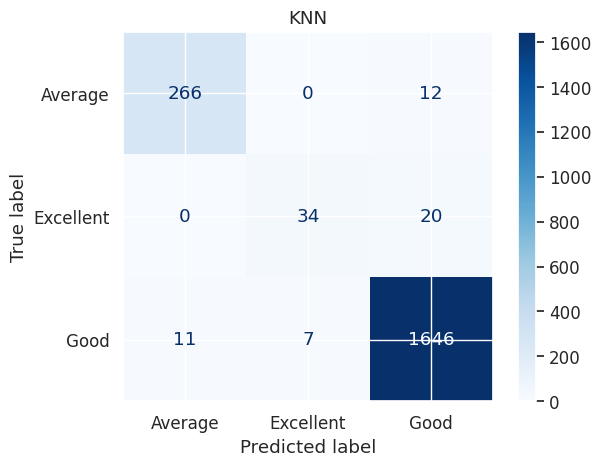

SVM
Accuracy : 0.9874749498997996
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       278
           1       0.89      0.78      0.83        54
           2       0.99      0.99      0.99      1664

    accuracy                           0.99      1996
   macro avg       0.96      0.92      0.94      1996
weighted avg       0.99      0.99      0.99      1996



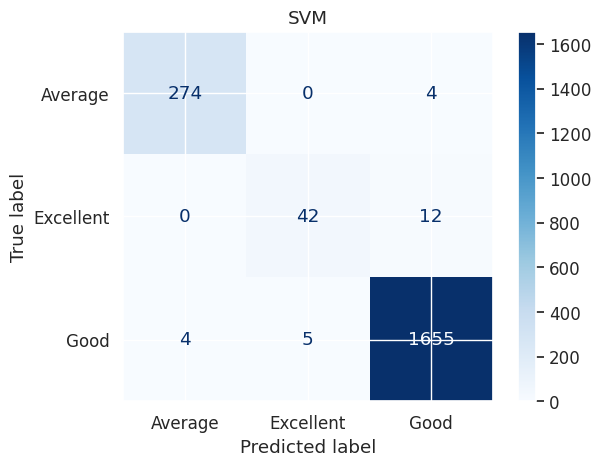

Naive Bayes
Accuracy : 0.9243486973947895
              precision    recall  f1-score   support

           0       0.74      0.95      0.83       278
           1       0.59      0.63      0.61        54
           2       0.98      0.93      0.95      1664

    accuracy                           0.92      1996
   macro avg       0.77      0.84      0.80      1996
weighted avg       0.93      0.92      0.93      1996



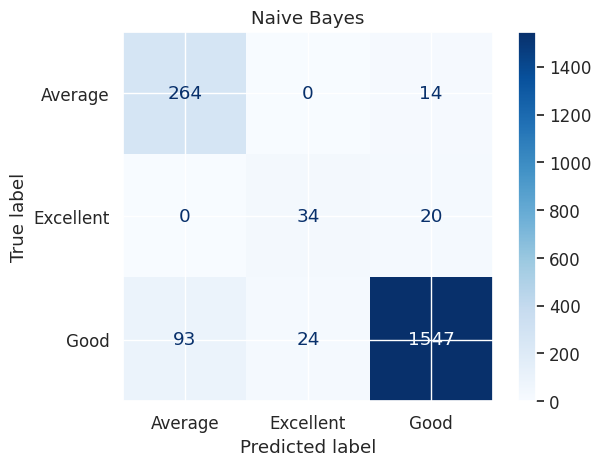

                 Model  Accuracy
1        Decision Tree  1.000000
3    Gradient Boosting  1.000000
2        Random Forest  0.998998
0  Logistic Regression  0.994990
5                  SVM  0.987475
4                  KNN  0.974950
6          Naive Bayes  0.924349


In [13]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

import matplotlib.pyplot as plt

# ==========================================================
# COPY DATA
# ==========================================================

data = df.copy()

# ==========================================================
# DROP USELESS COLUMNS
# ==========================================================

data.drop(
    columns=["Unnamed: 0","id","title"],
    inplace=True,
    errors="ignore"
)

# ==========================================================
# HANDLE MISSING VALUES
# ==========================================================

data["overview"] = data["overview"].fillna("No Overview")
data["release_date"] = pd.to_datetime(data["release_date"],errors="coerce")
data["release_year"] = data["release_date"].dt.year
data.drop(columns=["release_date","overview"], inplace=True)

# ==========================================================
# CREATE TARGET
# ==========================================================

data["rating_category"] = pd.cut(
    data["vote_average"],
    bins=[0,4,6,8,10],
    labels=["Poor","Average","Good","Excellent"]
)

data.dropna(inplace=True)

target="rating_category"

X=data.drop(columns=[target])

y=data[target]

# ==========================================================
# LABEL ENCODE
# ==========================================================

cat_cols=X.select_dtypes(include="object").columns

for col in cat_cols:
    le=LabelEncoder()
    X[col]=le.fit_transform(X[col].astype(str))

target_encoder=LabelEncoder()
y=target_encoder.fit_transform(y)

# ==========================================================
# TRAIN TEST SPLIT
# ==========================================================

X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ==========================================================
# IMPUTER
# ==========================================================

imputer=SimpleImputer(strategy="median")

X_train=imputer.fit_transform(X_train)
X_test=imputer.transform(X_test)

# ==========================================================
# SCALER
# ==========================================================

scaler=StandardScaler()

X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

# ==========================================================
# MODELS
# ==========================================================

models={

"Logistic Regression":LogisticRegression(max_iter=5000),

"Decision Tree":DecisionTreeClassifier(),

"Random Forest":RandomForestClassifier(),

"Gradient Boosting":GradientBoostingClassifier(),

"KNN":KNeighborsClassifier(),

"SVM":SVC(),

"Naive Bayes":GaussianNB()

}

# ==========================================================
# TRAIN
# ==========================================================

results=[]

for name,model in models.items():

    model.fit(X_train,y_train)

    pred=model.predict(X_test)

    acc=accuracy_score(y_test,pred)

    print("="*60)
    print(name)
    print("="*60)

    print("Accuracy :",acc)

    print(classification_report(y_test,pred))

    cm=confusion_matrix(y_test,pred)

    disp=ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=target_encoder.classes_
    )

    disp.plot(cmap="Blues")

    plt.title(name)

    plt.show()

    results.append([name,acc])

results=pd.DataFrame(
    results,
    columns=["Model","Accuracy"]
)

print(results.sort_values(by="Accuracy",ascending=False))